# Classification of Hand-Drawn UI Element Sketches Using CNN and Transfer Learning

This notebook is written as a clean, local-friendly and Colab-friendly project pipeline.

**Scope:**
- Custom CNN baseline
- EfficientNetB0 transfer learning
- EfficientNetB0 fine-tuning as the advanced step
- Optional Test-Time Augmentation
- No trained model saving

All results are saved as figures, CSV files, text reports and JSON summaries inside a timestamped output folder.

## Phase 1: Project Configuration

**Purpose:**  

This phase defines the project folder, dataset ZIP location, training settings and run options.  
Change only this phase when moving the project between Google Colab and your local computer.

In [16]:


from pathlib import Path
from datetime import datetime


# 1. Choose where the project should live


home_folder = Path.home()
desktop_folder = home_folder / "Desktop"

if desktop_folder.exists():
    PROJECT_ROOT = desktop_folder / "Anjali_CV_Project_WS"
else:
    PROJECT_ROOT = Path.cwd() / "Anjali_CV_Project_WS"

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)


# 2. Dataset ZIP location

# Put archive.zip inside PROJECT_ROOT, or update DATASET_ZIP_PATH manually.

DATASET_ZIP_PATH = PROJECT_ROOT / "archive.zip"


if not DATASET_ZIP_PATH.exists():
    possible_dataset_paths = [
        Path.cwd() / "archive.zip",
        Path("/content/archive.zip"),
        Path("/content/drive/MyDrive/uisketch_ieee_project/archive.zip"),
        Path("/mnt/data/archive.zip")
    ]

    for possible_path in possible_dataset_paths:
        if possible_path.exists():
            DATASET_ZIP_PATH = possible_path
            break


# 3. Main experiment settings

IMAGE_SIZE = 224
BATCH_SIZE = 32
RANDOM_SEED = 42

CUSTOM_CNN_EPOCHS = 25
EFFICIENTNET_HEAD_EPOCHS = 12
EFFICIENTNET_FINE_TUNE_EPOCHS = 8
FINE_TUNE_LAST_LAYERS = 30

VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15


# 4. Run options

RUN_CUSTOM_CNN = True
RUN_EFFICIENTNET_HEAD_TRAINING = True
RUN_EFFICIENTNET_FINE_TUNING = True
RUN_TEST_TIME_AUGMENTATION = False

# Keep False to avoid accidentally using old result files.
# Use True only when you intentionally want to skip phases where result files already exist.

SKIP_PHASE_IF_RESULT_EXISTS = False

# No trained model saving, as requested.

SAVE_TRAINED_MODELS = False

print("Project root:", PROJECT_ROOT)
print("Dataset ZIP path:", DATASET_ZIP_PATH)
print("Dataset ZIP exists:", DATASET_ZIP_PATH.exists())

Project root: /Users/anjali/Desktop/Anjali_CV_Project_WS
Dataset ZIP path: /Users/anjali/Desktop/Anjali_CV_Project_WS/archive.zip
Dataset ZIP exists: False


## Phase 2: Import Libraries and Set Reproducibility

**Purpose:**  
This phase imports all required libraries once and sets random seeds so the split and training process are as reproducible as possible.

In [17]:

# Phase 2: Import Libraries and Set Reproducibility


import os
import json
import time
import zipfile
import shutil
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.applications import EfficientNetB0

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

try:
    import seaborn as sns
except ImportError:
    sns = None

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


## Phase 3: Create Timestamped Output Folder

**Purpose:**  
This phase creates a new result folder for every run.  
This avoids overwriting previous outputs and protects important figures, CSV files and reports.

In [18]:
DATA_FOLDER = PROJECT_ROOT / "data"
OUTPUTS_FOLDER = PROJECT_ROOT / "outputs"
NOTEBOOKS_FOLDER = PROJECT_ROOT / "notebooks"
PAPER_FOLDER = PROJECT_ROOT / "paper"
PPT_FOLDER = PROJECT_ROOT / "ppt"

for folder in [DATA_FOLDER, OUTPUTS_FOLDER, NOTEBOOKS_FOLDER, PAPER_FOLDER, PPT_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RUN_FOLDER = OUTPUTS_FOLDER / f"run_{run_timestamp}"
FIGURES_FOLDER = RUN_FOLDER / "figures"
TABLES_FOLDER = RUN_FOLDER / "tables"
REPORTS_FOLDER = RUN_FOLDER / "reports"
LOGS_FOLDER = RUN_FOLDER / "logs"
SPLITS_FOLDER = RUN_FOLDER / "splits"

for folder in [RUN_FOLDER, FIGURES_FOLDER, TABLES_FOLDER, REPORTS_FOLDER, LOGS_FOLDER, SPLITS_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

print("Current run folder:", RUN_FOLDER)

Current run folder: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12


## Phase 4: Helper Functions for Saving Results

**Purpose:**  
This phase defines reusable saving functions.  
Only result files are saved. No trained model files are saved.

In [19]:

def save_dataframe(dataframe, save_path, include_index=False):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    dataframe.to_csv(save_path, index=include_index)
    print("Saved:", save_path)


def save_json(data, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4)
    print("Saved:", save_path)


def save_current_figure(save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print("Saved figure:", save_path)


def save_text(text, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as file:
        file.write(text)
    print("Saved:", save_path)


experiment_config = {
    "project_title": "Classification of Hand-Drawn UI Element Sketches Using CNN and Transfer Learning",
    "project_root": str(PROJECT_ROOT),
    "dataset_zip_path": str(DATASET_ZIP_PATH),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "random_seed": RANDOM_SEED,
    "split": "70% train, 15% validation, 15% test",
    "models": ["Custom CNN", "EfficientNetB0", "EfficientNetB0 Fine-Tuned"],
    "model_saving": "Disabled",
    "run_folder": str(RUN_FOLDER)
}

save_json(experiment_config, LOGS_FOLDER / "experiment_config.json")

Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/logs/experiment_config.json


## Phase 5: Extract and Locate Dataset

**Purpose:**  
This phase extracts the UISketch ZIP file and finds the folder that contains class-wise image folders.

In [20]:
EXTRACTED_DATASET_FOLDER = DATA_FOLDER / "uisketch_extracted"

# Check if DATASET folder already exists at PROJECT_ROOT
local_dataset_folder = PROJECT_ROOT / "DATASET"

if local_dataset_folder.exists() and len(list(local_dataset_folder.rglob("*.jpg"))) > 0:
    print("Using existing DATASET folder at:", local_dataset_folder)
    EXTRACTED_DATASET_FOLDER = local_dataset_folder

elif not EXTRACTED_DATASET_FOLDER.exists() or len(list(EXTRACTED_DATASET_FOLDER.rglob("*.jpg"))) == 0:
    if not DATASET_ZIP_PATH.exists():
        raise FileNotFoundError(
            f"Dataset ZIP file was not found at: {DATASET_ZIP_PATH}\n"
            f"Please either:\n"
            f"  1. Place archive.zip at {PROJECT_ROOT}, OR\n"
            f"  2. Place the extracted DATASET folder at {PROJECT_ROOT}"
        )
    
    print("Extracting dataset from ZIP...")
    if EXTRACTED_DATASET_FOLDER.exists():
        shutil.rmtree(EXTRACTED_DATASET_FOLDER)
    EXTRACTED_DATASET_FOLDER.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(DATASET_ZIP_PATH, "r") as zip_file:
        zip_file.extractall(EXTRACTED_DATASET_FOLDER)
    print("Dataset extracted successfully.")

else:
    print("Dataset already extracted at:", EXTRACTED_DATASET_FOLDER)


def count_images_in_folder(folder_path):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(1 for file_path in folder_path.rglob("*") if file_path.suffix.lower() in image_extensions)


def find_class_folder(dataset_root):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    candidate_folders = []

    for folder_path in [dataset_root] + [path for path in dataset_root.rglob("*") if path.is_dir()]:
        if "__MACOSX" in str(folder_path):
            continue

        child_folders = [child for child in folder_path.iterdir() if child.is_dir()]
        image_child_folders = []

        for child in child_folders:
            image_count = sum(1 for file in child.iterdir() if file.is_file() and file.suffix.lower() in image_extensions)
            if image_count > 0:
                image_child_folders.append(child)

        if len(image_child_folders) >= 2:
            total_images = count_images_in_folder(folder_path)
            candidate_folders.append((folder_path, len(image_child_folders), total_images))

    if not candidate_folders:
        raise RuntimeError("Could not find class-wise dataset folders after extraction.")

    candidate_folders = sorted(candidate_folders, key=lambda item: item[2], reverse=True)
    return candidate_folders[0][0]


DATASET_FOLDER = find_class_folder(EXTRACTED_DATASET_FOLDER)

print("Dataset folder:", DATASET_FOLDER)
print("Total images found:", count_images_in_folder(DATASET_FOLDER))

Using existing DATASET folder at: /Users/anjali/Desktop/Anjali_CV_Project_WS/DATASET
Dataset folder: /Users/anjali/Desktop/Anjali_CV_Project_WS/DATASET
Total images found: 19898


## Phase 6: Build Dataset Table and Inspect Dataset

**Purpose:**  
This phase creates a clean table containing image paths and class labels.  
It also saves dataset summary files needed for the paper and presentation.

In [21]:

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
rows = []

for class_folder in sorted([path for path in DATASET_FOLDER.iterdir() if path.is_dir()]):
    if class_folder.name.startswith(".") or class_folder.name == "__MACOSX":
        continue

    for image_path in sorted(class_folder.iterdir()):
        if image_path.is_file() and image_path.suffix.lower() in image_extensions:
            rows.append({
                "image_path": str(image_path),
                "class_name": class_folder.name,
                "image_name": image_path.name,
                "image_format": image_path.suffix.lower().replace(".", "")
            })

dataset_dataframe = pd.DataFrame(rows)

if dataset_dataframe.empty:
    raise RuntimeError("No images were found. Please check the dataset folder structure.")

class_names = sorted(dataset_dataframe["class_name"].unique().tolist())
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}
number_of_classes = len(class_names)

dataset_dataframe["class_index"] = dataset_dataframe["class_name"].map(class_to_index).astype("int32")

class_distribution = (
    dataset_dataframe
    .groupby("class_name")
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

dataset_summary = pd.DataFrame([
    {"item": "total_images", "value": len(dataset_dataframe)},
    {"item": "number_of_classes", "value": number_of_classes},
    {"item": "image_size_for_training", "value": f"{IMAGE_SIZE}x{IMAGE_SIZE}"},
    {"item": "batch_size", "value": BATCH_SIZE}
])

save_dataframe(dataset_dataframe, TABLES_FOLDER / "dataset_image_paths.csv")
save_dataframe(class_distribution, TABLES_FOLDER / "class_distribution.csv")
save_dataframe(dataset_summary, TABLES_FOLDER / "dataset_summary.csv")
save_json(class_to_index, LOGS_FOLDER / "class_mapping.json")

print("Total images:", len(dataset_dataframe))
print("Number of classes:", number_of_classes)
display(class_distribution.head(10))

Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/tables/dataset_image_paths.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/tables/class_distribution.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/tables/dataset_summary.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/logs/class_mapping.json
Total images: 19898
Number of classes: 21


,class_name,image_count
1,button,1157
10,image,1119
19,text_field,1109
4,checkbox_unchecked,1054
11,label,1054
3,checkbox_checked,1041
2,card,972
14,radio_button_unchecked,947
17,switch_enabled,927
8,floating_action_button,919


## Phase 7: Visual Dataset Inspection

**Purpose:**  
This phase saves the class distribution chart, dataset sample grid and image size check.  
These outputs are useful for the dataset section of the IEEE paper.

Saved figure: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/figures/class_distribution.png


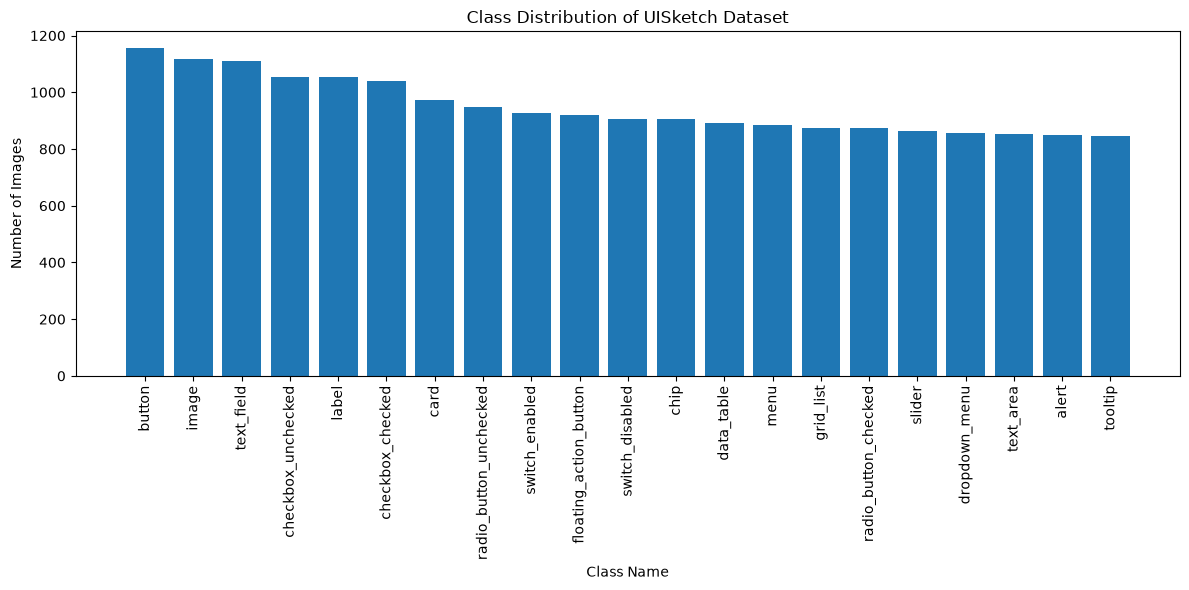

Saved figure: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/figures/dataset_samples.png


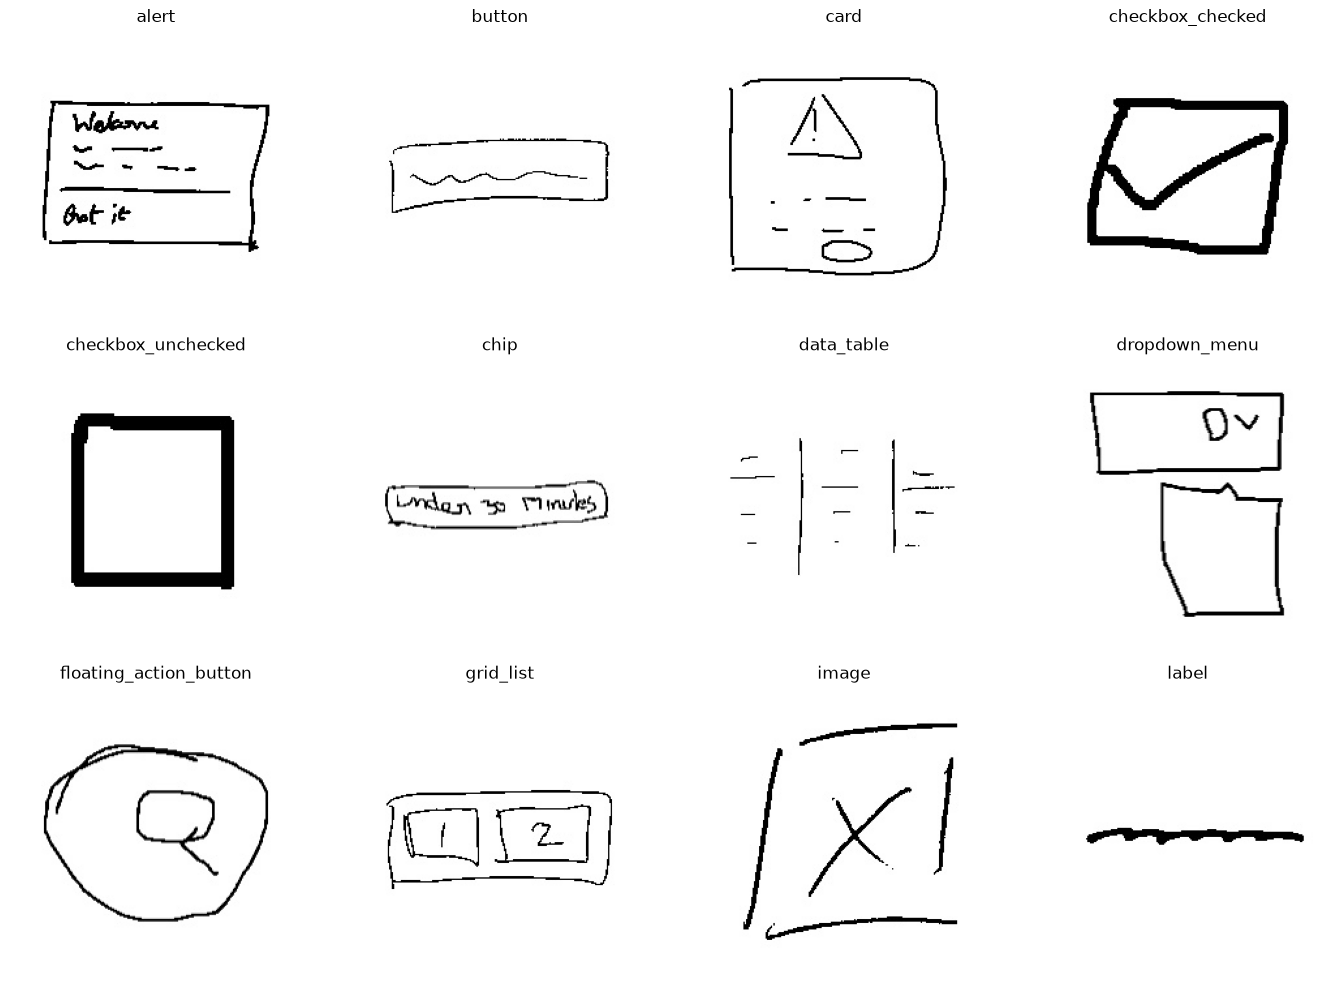

Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/tables/sample_image_size_check.csv


,image_path,width,height,mode
0,/Users/anjali/Desktop/Anjali_CV_Project_WS/DAT...,224,224,RGB
1,/Users/anjali/Desktop/Anjali_CV_Project_WS/DAT...,224,224,RGB
2,/Users/anjali/Desktop/Anjali_CV_Project_WS/DAT...,224,224,RGB
3,/Users/anjali/Desktop/Anjali_CV_Project_WS/DAT...,224,224,RGB
4,/Users/anjali/Desktop/Anjali_CV_Project_WS/DAT...,224,224,RGB


Most common image sizes:


,width,height,count
0,224,224,300


In [22]:

# Class distribution figure

plt.figure(figsize=(12, 6))
plt.bar(class_distribution["class_name"], class_distribution["image_count"])
plt.title("Class Distribution of UISketch Dataset")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
save_current_figure(FIGURES_FOLDER / "class_distribution.png")
plt.show()


# Dataset sample grid

sample_classes = class_names[:12]
plt.figure(figsize=(14, 10))

for position, class_name in enumerate(sample_classes):
    sample_path = dataset_dataframe[dataset_dataframe["class_name"] == class_name].iloc[0]["image_path"]
    image = Image.open(sample_path).convert("RGB")

    plt.subplot(3, 4, position + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
save_current_figure(FIGURES_FOLDER / "dataset_samples.png")
plt.show()


# Image size and mode check

sample_size_rows = []
for image_path in dataset_dataframe["image_path"].sample(min(300, len(dataset_dataframe)), random_state=RANDOM_SEED):
    with Image.open(image_path) as image:
        sample_size_rows.append({
            "image_path": image_path,
            "width": image.width,
            "height": image.height,
            "mode": image.mode
        })

sample_image_size_check = pd.DataFrame(sample_size_rows)
save_dataframe(sample_image_size_check, TABLES_FOLDER / "sample_image_size_check.csv")

display(sample_image_size_check.head())
print("Most common image sizes:")
display(sample_image_size_check.groupby(["width", "height"]).size().reset_index(name="count").sort_values("count", ascending=False).head())

## Phase 8: Stratified Train/Validation/Test Split

**Purpose:**  
This phase creates a fixed 70/15/15 split while preserving the class distribution.  
The split files are saved so the experiment can be documented clearly.

In [23]:


train_dataframe, temporary_dataframe = train_test_split(
    dataset_dataframe,
    test_size=(VALIDATION_SIZE + TEST_SIZE),
    stratify=dataset_dataframe["class_name"],
    random_state=RANDOM_SEED
)

validation_relative_size = VALIDATION_SIZE / (VALIDATION_SIZE + TEST_SIZE)

test_dataframe, validation_dataframe = train_test_split(
    temporary_dataframe,
    test_size=validation_relative_size,
    stratify=temporary_dataframe["class_name"],
    random_state=RANDOM_SEED
)

train_dataframe = train_dataframe.reset_index(drop=True)
validation_dataframe = validation_dataframe.reset_index(drop=True)
test_dataframe = test_dataframe.reset_index(drop=True)

split_summary = pd.DataFrame([
    {"split": "train", "images": len(train_dataframe)},
    {"split": "validation", "images": len(validation_dataframe)},
    {"split": "test", "images": len(test_dataframe)}
])

save_dataframe(train_dataframe, SPLITS_FOLDER / "train_split.csv")
save_dataframe(validation_dataframe, SPLITS_FOLDER / "validation_split.csv")
save_dataframe(test_dataframe, SPLITS_FOLDER / "test_split.csv")
save_dataframe(split_summary, TABLES_FOLDER / "split_summary.csv")

print("Train images:", len(train_dataframe))
print("Validation images:", len(validation_dataframe))
print("Test images:", len(test_dataframe))
display(split_summary)

Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/splits/train_split.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/splits/validation_split.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/splits/test_split.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/tables/split_summary.csv
Train images: 13928
Validation images: 2985
Test images: 2985


,split,images
0,train,13928
1,validation,2985
2,test,2985


## Phase 9: TensorFlow Data Pipeline

**Purpose:**  
This phase converts the split dataframes into TensorFlow datasets.  
Images are kept in the 0–255 range because EfficientNetB0 includes its own preprocessing internally.  
The Custom CNN handles scaling inside its own model.

In [24]:


train_dataframe = train_dataframe.copy()
validation_dataframe = validation_dataframe.copy()
test_dataframe = test_dataframe.copy()

train_dataframe["label"] = train_dataframe["class_name"].map(class_to_index).astype("int32")
validation_dataframe["label"] = validation_dataframe["class_name"].map(class_to_index).astype("int32")
test_dataframe["label"] = test_dataframe["class_name"].map(class_to_index).astype("int32")

AUTOTUNE = tf.data.AUTOTUNE


def load_image_for_training(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32)
    image.set_shape([IMAGE_SIZE, IMAGE_SIZE, 3])
    return image, label


data_augmentation = tf.keras.Sequential(
    [
        layers.RandomRotation(0.04),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.06, 0.06),
    ],
    name="light_sketch_augmentation"
)


def apply_augmentation(image, label):
    image = data_augmentation(image, training=True)
    return image, label


def create_tensorflow_dataset(dataframe, training=False):
    image_paths = dataframe["image_path"].astype(str).values
    labels = dataframe["label"].astype("int32").values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image_for_training, num_parallel_calls=AUTOTUNE)

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )
        dataset = dataset.map(apply_augmentation, num_parallel_calls=AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset


train_data = create_tensorflow_dataset(train_dataframe, training=True)
validation_data = create_tensorflow_dataset(validation_dataframe, training=False)
test_data = create_tensorflow_dataset(test_dataframe, training=False)

print("TensorFlow datasets prepared successfully.")
print("Train batches:", len(train_data))
print("Validation batches:", len(validation_data))
print("Test batches:", len(test_data))

TensorFlow datasets prepared successfully.
Train batches: 436
Validation batches: 94
Test batches: 94


## Phase 10: Evaluation and Visualization Functions

**Purpose:**  
This phase defines reusable functions for training curves, classification reports, confusion matrices and misclassified examples.

In [25]:


def save_training_history(history, save_path):
    history_dataframe = pd.DataFrame(history.history)
    save_dataframe(history_dataframe, save_path)
    return history_dataframe


def plot_training_curves(history_dataframe, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history_dataframe["accuracy"], label="Training Accuracy")
    plt.plot(history_dataframe["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    save_current_figure(FIGURES_FOLDER / f"{model_name}_accuracy_curve.png")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_dataframe["loss"], label="Training Loss")
    plt.plot(history_dataframe["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    save_current_figure(FIGURES_FOLDER / f"{model_name}_loss_curve.png")
    plt.show()


def evaluate_model(model, test_dataset, class_names, model_name):
    true_labels = []
    predicted_labels = []
    predicted_probabilities = []

    for images, labels in test_dataset:
        probabilities = model.predict(images, verbose=0)
        predictions = np.argmax(probabilities, axis=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions)
        predicted_probabilities.extend(probabilities)

    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    predicted_probabilities = np.array(predicted_probabilities)

    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )

    metrics = {
        "model_name": model_name,
        "accuracy": float(accuracy),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1_score": float(macro_f1)
    }

    report_text = classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        zero_division=0
    )

    save_text(report_text, REPORTS_FOLDER / f"{model_name}_classification_report.txt")

    report_dictionary = classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_dataframe = pd.DataFrame(report_dictionary).transpose()
    save_dataframe(report_dataframe, REPORTS_FOLDER / f"{model_name}_classification_report.csv", include_index=True)

    matrix = confusion_matrix(true_labels, predicted_labels)
    matrix_dataframe = pd.DataFrame(matrix, index=class_names, columns=class_names)
    save_dataframe(matrix_dataframe, REPORTS_FOLDER / f"{model_name}_confusion_matrix.csv", include_index=True)

    plt.figure(figsize=(15, 12))
    if sns is not None:
        sns.heatmap(matrix_dataframe, cmap="Blues", annot=False, fmt="d")
    else:
        plt.imshow(matrix, interpolation="nearest")
        plt.colorbar()

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    save_current_figure(FIGURES_FOLDER / f"{model_name}_confusion_matrix.png")
    plt.show()

    print(report_text)
    return metrics, true_labels, predicted_labels, predicted_probabilities


def show_misclassified_examples(test_dataframe, true_labels, predicted_labels, class_names, model_name, number_of_examples=6):
    wrong_indices = np.where(true_labels != predicted_labels)[0]

    if len(wrong_indices) == 0:
        print("No misclassified examples found.")
        return

    selected_indices = wrong_indices[:number_of_examples]

    plt.figure(figsize=(15, 8))
    for position, sample_index in enumerate(selected_indices):
        image_path = test_dataframe.iloc[sample_index]["image_path"]
        image = Image.open(image_path).convert("RGB")

        true_class = class_names[int(true_labels[sample_index])]
        predicted_class = class_names[int(predicted_labels[sample_index])]

        plt.subplot(2, 3, position + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"True: {true_class}\nPredicted: {predicted_class}")

    plt.tight_layout()
    save_current_figure(FIGURES_FOLDER / f"{model_name}_misclassified_examples.png")
    plt.show()

## Phase 11: Build Custom CNN Baseline

**Purpose:**  
This phase builds a simple CNN baseline.  
The model includes internal rescaling because the TensorFlow pipeline provides images in the 0–255 range.

In [26]:


def build_custom_cnn(number_of_classes):
    model = models.Sequential(
        [
            layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
            layers.Rescaling(1.0 / 255.0),

            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D(),

            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D(),

            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D(),

            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.4),

            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),

            layers.Dense(number_of_classes, activation="softmax")
        ],
        name="custom_cnn_baseline"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


custom_cnn_model = build_custom_cnn(number_of_classes)
custom_cnn_model.summary()

Model: "custom_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,469 (439.33 KB)

 Trainable params: 112,469 (439.33 KB)

 Non-trainable params: 0 (0.00 B)

## Phase 12: Train and Evaluate Custom CNN Baseline

**Purpose:**  
This phase trains the Custom CNN and saves all results except the trained model file.

Epoch 1/25


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


436/436 ━━━━━━━━━━━━━━━━━━━━ 276s 626ms/step - accuracy: 0.0827 - loss: 2.9055 - val_accuracy: 0.1578 - val_loss: 2.6037 - learning_rate: 0.0010
Epoch 2/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 294s 669ms/step - accuracy: 0.1794 - loss: 2.5155 - val_accuracy: 0.2693 - val_loss: 2.2425 - learning_rate: 0.0010
Epoch 3/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 299s 680ms/step - accuracy: 0.2420 - loss: 2.3084 - val_accuracy: 0.3075 - val_loss: 2.1646 - learning_rate: 0.0010
Epoch 4/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 365s 832ms/step - accuracy: 0.2850 - loss: 2.1954 - val_accuracy: 0.3615 - val_loss: 2.0238 - learning_rate: 0.0010
Epoch 5/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.3110 - loss: 2.1284 - val_accuracy: 0.3853 - val_loss: 1.9474 - learning_rate: 0.0010
Epoch 6/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 368s 837ms/step - accuracy: 0.3247 - loss: 2.0778 - val_accuracy: 0.3936 - val_loss: 1.8787 - learning_rate: 0.0010
Epoch 7/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 364s 828ms/step - accuracy: 0.3425 - l

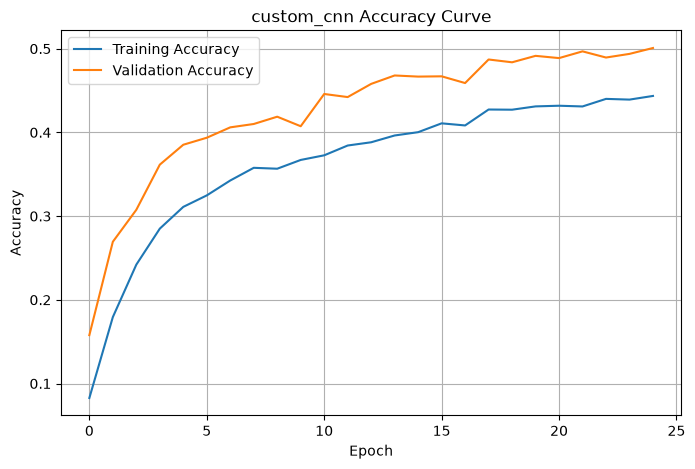

Saved figure: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/figures/custom_cnn_loss_curve.png


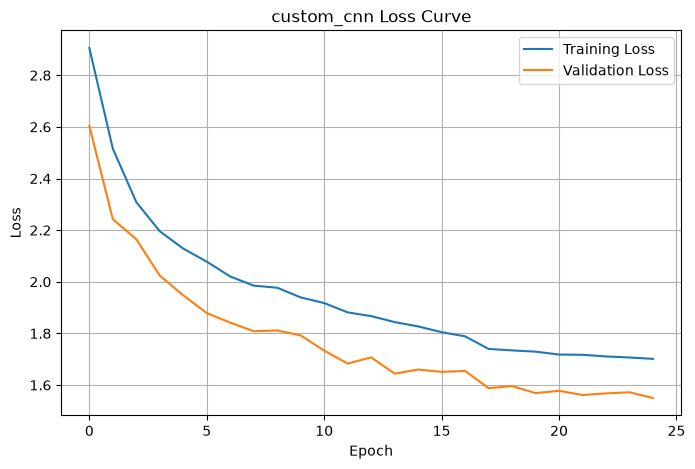

Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/custom_cnn_classification_report.txt
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/custom_cnn_classification_report.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/custom_cnn_confusion_matrix.csv
Saved figure: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/figures/custom_cnn_confusion_matrix.png


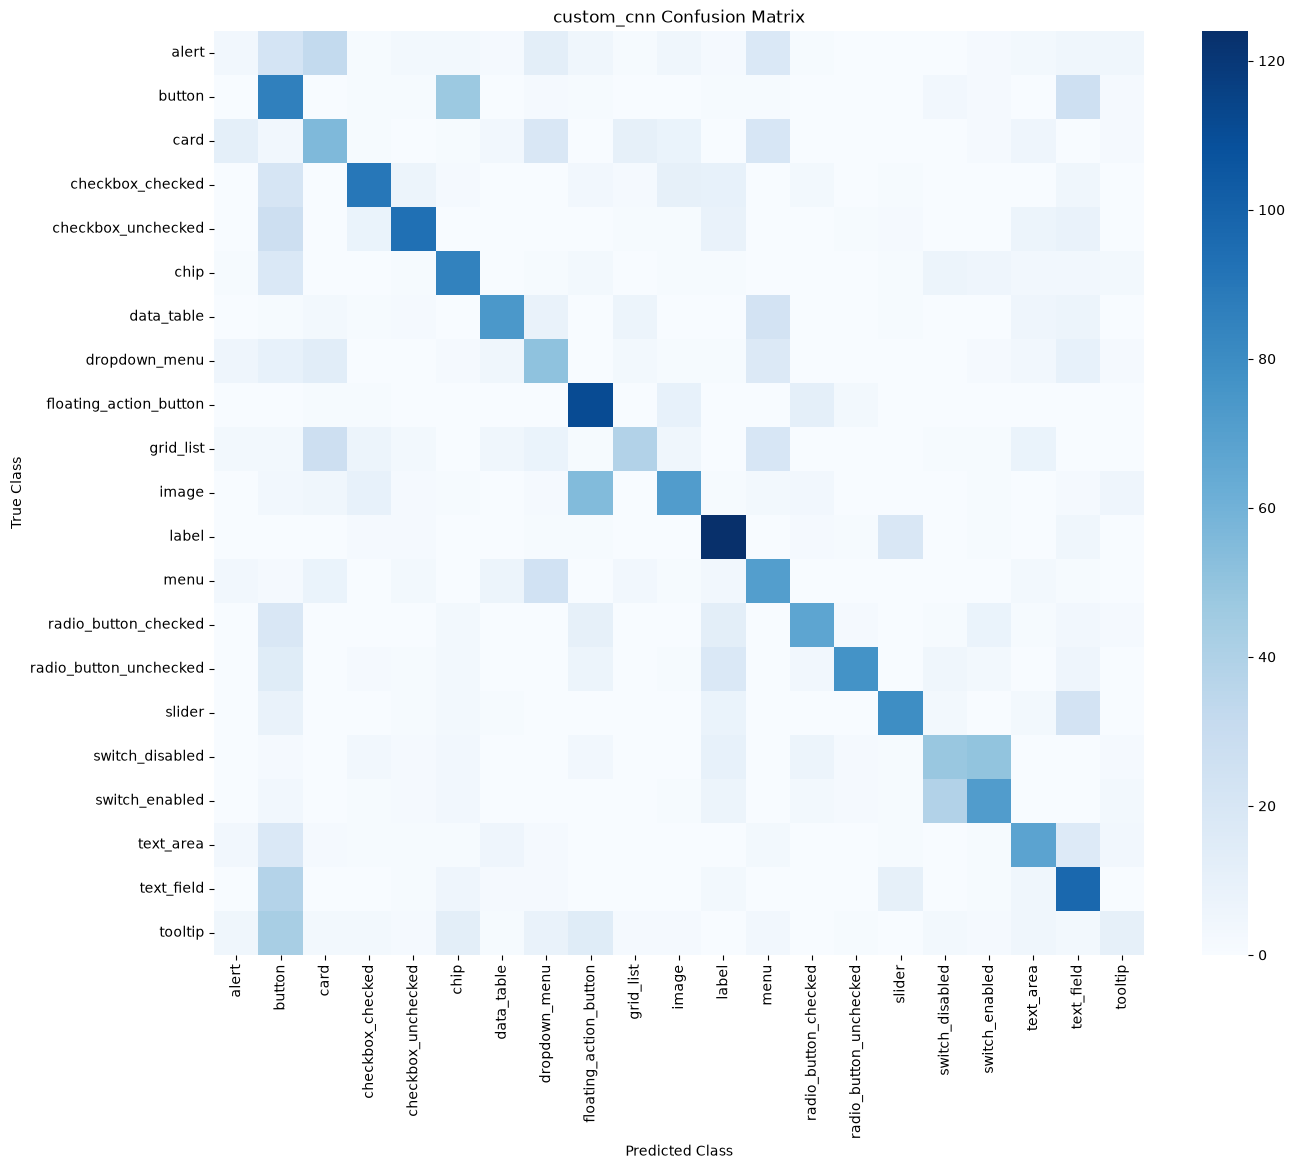

                        precision    recall  f1-score   support

                 alert       0.10      0.03      0.05       127
                button       0.25      0.49      0.33       174
                  card       0.37      0.38      0.38       146
      checkbox_checked       0.68      0.58      0.62       156
    checkbox_unchecked       0.73      0.59      0.65       158
                  chip       0.48      0.62      0.54       136
            data_table       0.69      0.55      0.61       134
         dropdown_menu       0.36      0.40      0.38       128
floating_action_button       0.51      0.80      0.62       138
             grid_list       0.56      0.30      0.39       131
                 image       0.61      0.43      0.50       168
                 label       0.58      0.78      0.67       158
                  menu       0.39      0.54      0.46       132
  radio_button_checked       0.65      0.51      0.57       131
radio_button_unchecked       0.87      

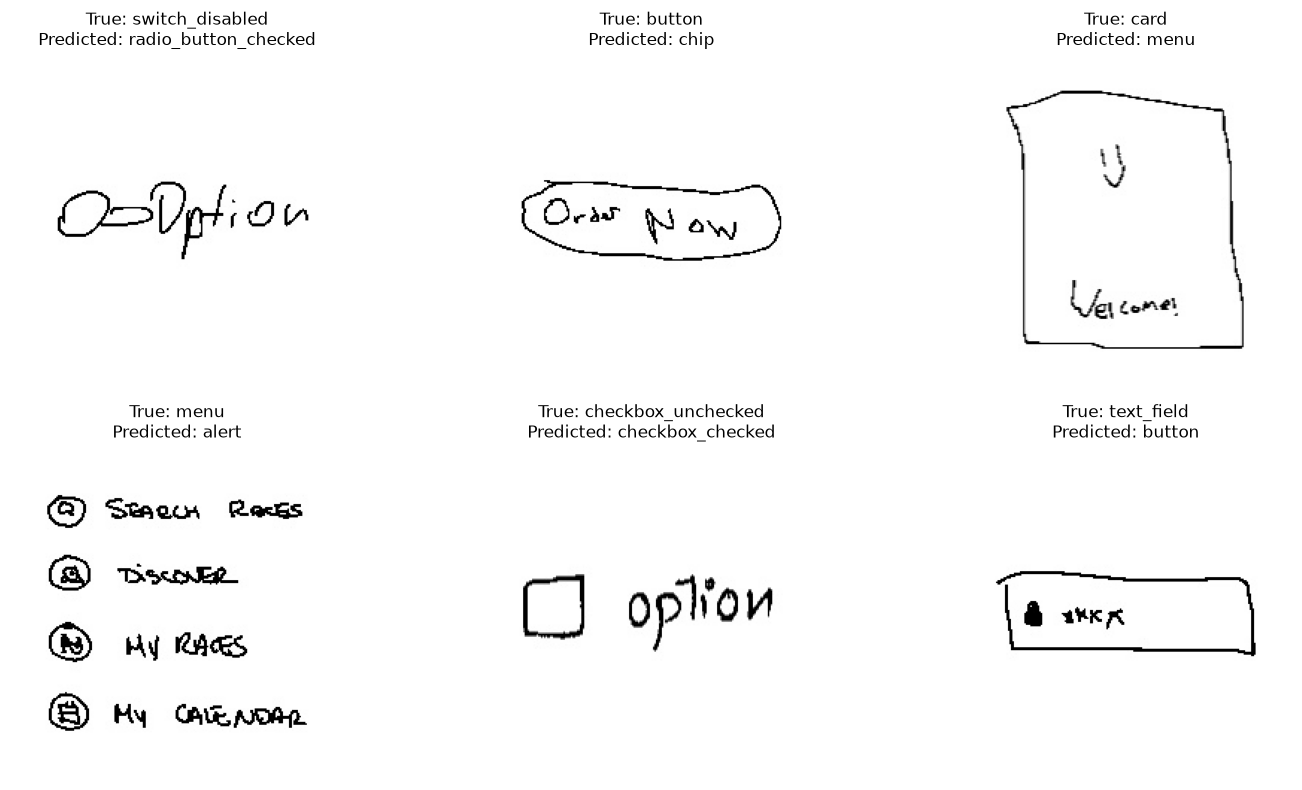

Custom CNN training time in minutes: 170.95


In [27]:


custom_cnn_metrics = None

if not RUN_CUSTOM_CNN:
    print("Custom CNN training is disabled in Phase 1 configuration.")

else:
    custom_cnn_metrics_file = REPORTS_FOLDER / "custom_cnn_metrics.csv"

    if SKIP_PHASE_IF_RESULT_EXISTS and custom_cnn_metrics_file.exists():
        print("Custom CNN metrics already exist. Skipping this phase.")
        custom_cnn_metrics = pd.read_csv(custom_cnn_metrics_file).iloc[0].to_dict()

    else:
        custom_cnn_callbacks = [
            EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
            CSVLogger(filename=str(LOGS_FOLDER / "custom_cnn_training_log.csv"))
        ]

        start_time = time.time()
        custom_cnn_history = custom_cnn_model.fit(
            train_data,
            validation_data=validation_data,
            epochs=CUSTOM_CNN_EPOCHS,
            callbacks=custom_cnn_callbacks,
            verbose=1
        )
        custom_cnn_training_time = round((time.time() - start_time) / 60, 2)

        custom_cnn_history_dataframe = save_training_history(
            custom_cnn_history,
            LOGS_FOLDER / "custom_cnn_training_history.csv"
        )
        plot_training_curves(custom_cnn_history_dataframe, "custom_cnn")

        custom_cnn_metrics, custom_true_labels, custom_predicted_labels, custom_probabilities = evaluate_model(
            custom_cnn_model,
            test_data,
            class_names,
            "custom_cnn"
        )
        custom_cnn_metrics["training_time_minutes"] = custom_cnn_training_time

        save_dataframe(pd.DataFrame([custom_cnn_metrics]), custom_cnn_metrics_file)
        show_misclassified_examples(test_dataframe, custom_true_labels, custom_predicted_labels, class_names, "custom_cnn")

        print("Custom CNN training time in minutes:", custom_cnn_training_time)

## Phase 13: Build EfficientNetB0 Transfer Learning Model

**Purpose:**  
This phase builds EfficientNetB0 with ImageNet weights.  
The base model is frozen first, and a new classification head is added for the 21 UI sketch classes.

In [28]:


def build_efficientnetb0_model(number_of_classes):
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )
    base_model.trainable = False

    input_layer = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = base_model(input_layer, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    output_layer = layers.Dense(number_of_classes, activation="softmax")(x)

    model = models.Model(
        inputs=input_layer,
        outputs=output_layer,
        name="efficientnetb0_transfer_learning"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model


efficientnet_model, efficientnet_base_model = build_efficientnetb0_model(number_of_classes)
efficientnet_model.summary()

Model: "efficientnetb0_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 21)             │        26,901 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,076,472 (15.55 MB)

 Trainable params: 26,901 (105.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Phase 14: Train and Evaluate EfficientNetB0 Frozen Model

**Purpose:**  
This phase trains only the new classification head while the EfficientNetB0 base remains frozen.

Epoch 1/12


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


436/436 ━━━━━━━━━━━━━━━━━━━━ 288s 645ms/step - accuracy: 0.5234 - loss: 1.5629 - val_accuracy: 0.5903 - val_loss: 1.2721 - learning_rate: 0.0010
Epoch 2/12
436/436 ━━━━━━━━━━━━━━━━━━━━ 319s 725ms/step - accuracy: 0.6464 - loss: 1.1268 - val_accuracy: 0.6385 - val_loss: 1.1263 - learning_rate: 0.0010
Epoch 3/12
436/436 ━━━━━━━━━━━━━━━━━━━━ 383s 873ms/step - accuracy: 0.6788 - loss: 1.0268 - val_accuracy: 0.6422 - val_loss: 1.0960 - learning_rate: 0.0010
Epoch 4/12
436/436 ━━━━━━━━━━━━━━━━━━━━ 399s 909ms/step - accuracy: 0.6903 - loss: 0.9648 - val_accuracy: 0.6576 - val_loss: 1.0644 - learning_rate: 0.0010
Epoch 5/12
436/436 ━━━━━━━━━━━━━━━━━━━━ 373s 846ms/step - accuracy: 0.7055 - loss: 0.9235 - val_accuracy: 0.6556 - val_loss: 1.0461 - learning_rate: 0.0010
Epoch 6/12
436/436 ━━━━━━━━━━━━━━━━━━━━ 356s 811ms/step - accuracy: 0.7081 - loss: 0.9074 - val_accuracy: 0.6734 - val_loss: 0.9994 - learning_rate: 0.0010
Epoch 7/12
436/436 ━━━━━━━━━━━━━━━━━━━━ 385s 875ms/step - accuracy: 0.7138 

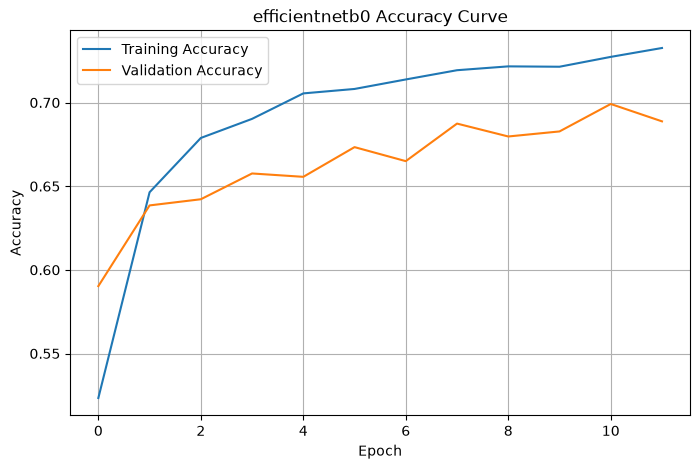

Saved figure: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/figures/efficientnetb0_loss_curve.png


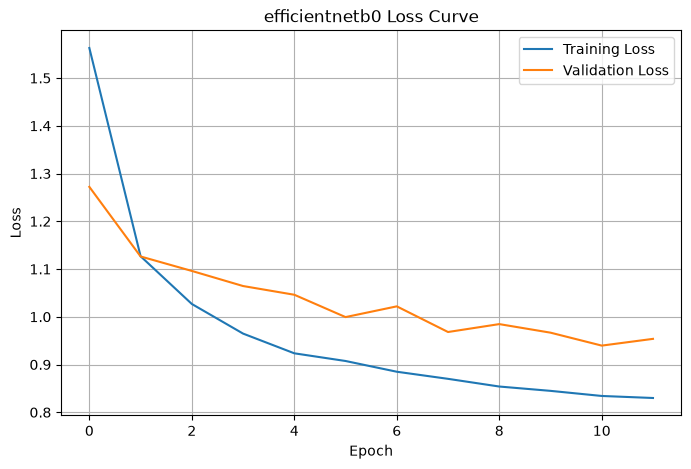

Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/efficientnetb0_classification_report.txt
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/efficientnetb0_classification_report.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/efficientnetb0_confusion_matrix.csv
Saved figure: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/figures/efficientnetb0_confusion_matrix.png


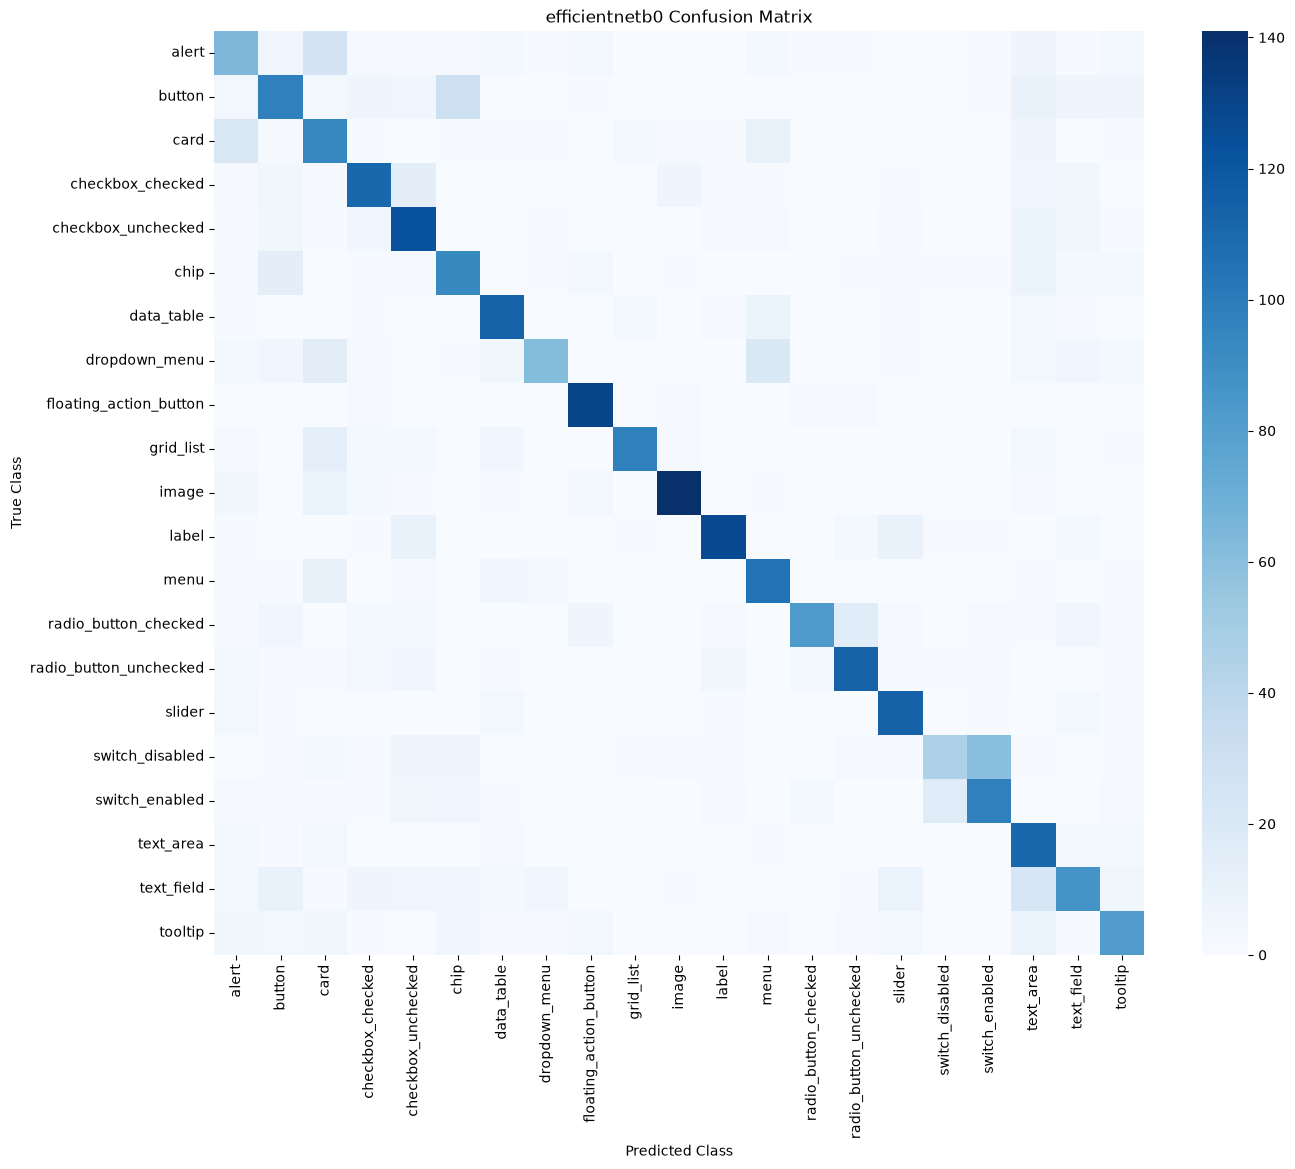

                        precision    recall  f1-score   support

                 alert       0.48      0.50      0.49       127
                button       0.61      0.56      0.59       174
                  card       0.49      0.64      0.56       146
      checkbox_checked       0.71      0.71      0.71       156
    checkbox_unchecked       0.65      0.78      0.71       158
                  chip       0.62      0.68      0.65       136
            data_table       0.77      0.84      0.81       134
         dropdown_menu       0.82      0.48      0.61       128
floating_action_button       0.84      0.94      0.89       138
             grid_list       0.92      0.75      0.83       131
                 image       0.89      0.84      0.87       168
                 label       0.87      0.80      0.84       158
                  menu       0.68      0.80      0.73       132
  radio_button_checked       0.90      0.63      0.74       131
radio_button_unchecked       0.80      

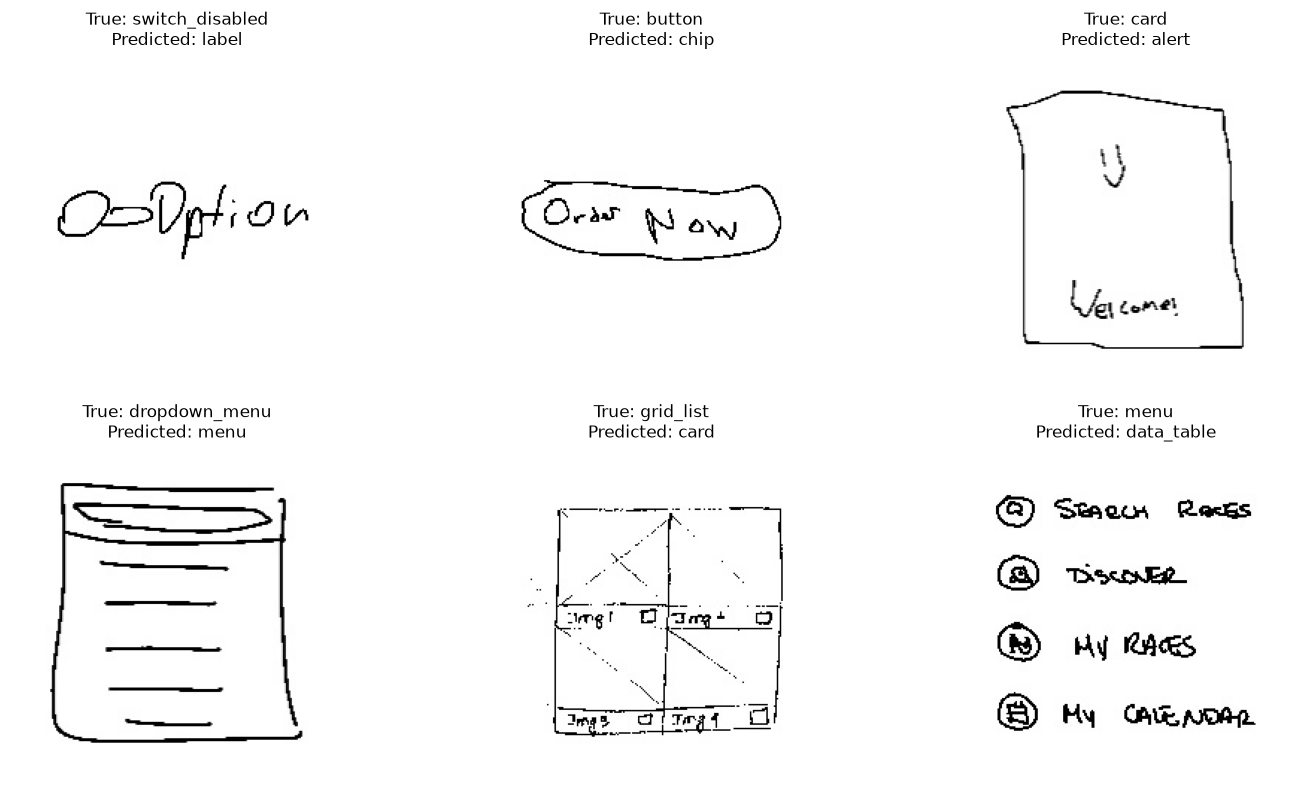

EfficientNetB0 frozen training time in minutes: 70.12


In [29]:


efficientnet_metrics = None
efficientnet_head_trained_in_this_session = False

if not RUN_EFFICIENTNET_HEAD_TRAINING:
    print("EfficientNetB0 head training is disabled in Phase 1 configuration.")

else:
    efficientnet_metrics_file = REPORTS_FOLDER / "efficientnetb0_metrics.csv"

    if SKIP_PHASE_IF_RESULT_EXISTS and efficientnet_metrics_file.exists():
        print("EfficientNetB0 metrics already exist. Skipping this phase.")
        print("Fine-tuning requires a trained model in memory, so Phase 15 should not be run after skipping Phase 14.")
        efficientnet_metrics = pd.read_csv(efficientnet_metrics_file).iloc[0].to_dict()

    else:
        efficientnet_callbacks = [
            EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
            CSVLogger(filename=str(LOGS_FOLDER / "efficientnetb0_training_log.csv"))
        ]

        start_time = time.time()
        efficientnet_history = efficientnet_model.fit(
            train_data,
            validation_data=validation_data,
            epochs=EFFICIENTNET_HEAD_EPOCHS,
            callbacks=efficientnet_callbacks,
            verbose=1
        )
        efficientnet_training_time = round((time.time() - start_time) / 60, 2)
        efficientnet_head_trained_in_this_session = True

        efficientnet_history_dataframe = save_training_history(
            efficientnet_history,
            LOGS_FOLDER / "efficientnetb0_training_history.csv"
        )
        plot_training_curves(efficientnet_history_dataframe, "efficientnetb0")

        efficientnet_metrics, efficientnet_true_labels, efficientnet_predicted_labels, efficientnet_probabilities = evaluate_model(
            efficientnet_model,
            test_data,
            class_names,
            "efficientnetb0"
        )
        efficientnet_metrics["training_time_minutes"] = efficientnet_training_time

        save_dataframe(pd.DataFrame([efficientnet_metrics]), efficientnet_metrics_file)
        show_misclassified_examples(test_dataframe, efficientnet_true_labels, efficientnet_predicted_labels, class_names, "efficientnetb0")

        print("EfficientNetB0 frozen training time in minutes:", efficientnet_training_time)

## Phase 15: Fine-Tune EfficientNetB0

**Purpose:**  
This is the advanced improvement step.  
The last EfficientNetB0 layers are unfrozen and trained with a very low learning rate.  
Because model saving is disabled, this phase should run immediately after Phase 14 in the same session.

Epoch 1/8


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


436/436 ━━━━━━━━━━━━━━━━━━━━ 270s 603ms/step - accuracy: 0.7469 - loss: 0.7839 - val_accuracy: 0.7146 - val_loss: 0.8981 - learning_rate: 1.0000e-05
Epoch 2/8
436/436 ━━━━━━━━━━━━━━━━━━━━ 351s 798ms/step - accuracy: 0.7537 - loss: 0.7472 - val_accuracy: 0.7186 - val_loss: 0.8874 - learning_rate: 1.0000e-05
Epoch 3/8
436/436 ━━━━━━━━━━━━━━━━━━━━ 353s 801ms/step - accuracy: 0.7568 - loss: 0.7383 - val_accuracy: 0.7229 - val_loss: 0.8720 - learning_rate: 1.0000e-05
Epoch 4/8
436/436 ━━━━━━━━━━━━━━━━━━━━ 309s 703ms/step - accuracy: 0.7625 - loss: 0.7242 - val_accuracy: 0.7233 - val_loss: 0.8651 - learning_rate: 1.0000e-05
Epoch 5/8
436/436 ━━━━━━━━━━━━━━━━━━━━ 368s 838ms/step - accuracy: 0.7721 - loss: 0.7035 - val_accuracy: 0.7266 - val_loss: 0.8455 - learning_rate: 1.0000e-05
Epoch 6/8
436/436 ━━━━━━━━━━━━━━━━━━━━ 385s 878ms/step - accuracy: 0.7711 - loss: 0.6934 - val_accuracy: 0.7286 - val_loss: 0.8383 - learning_rate: 1.0000e-05
Epoch 7/8
436/436 ━━━━━━━━━━━━━━━━━━━━ 364s 829ms/step -

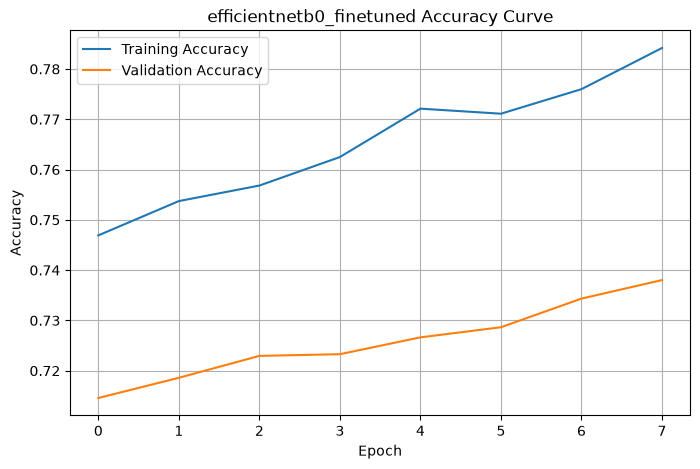

Saved figure: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/figures/efficientnetb0_finetuned_loss_curve.png


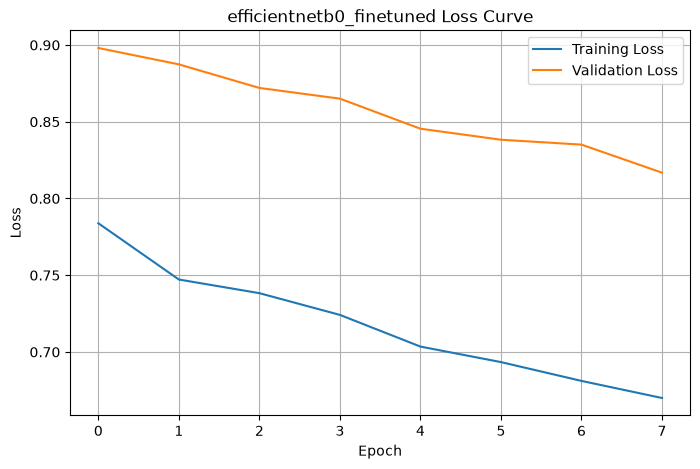

Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/efficientnetb0_finetuned_classification_report.txt
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/efficientnetb0_finetuned_classification_report.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/reports/efficientnetb0_finetuned_confusion_matrix.csv
Saved figure: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/figures/efficientnetb0_finetuned_confusion_matrix.png


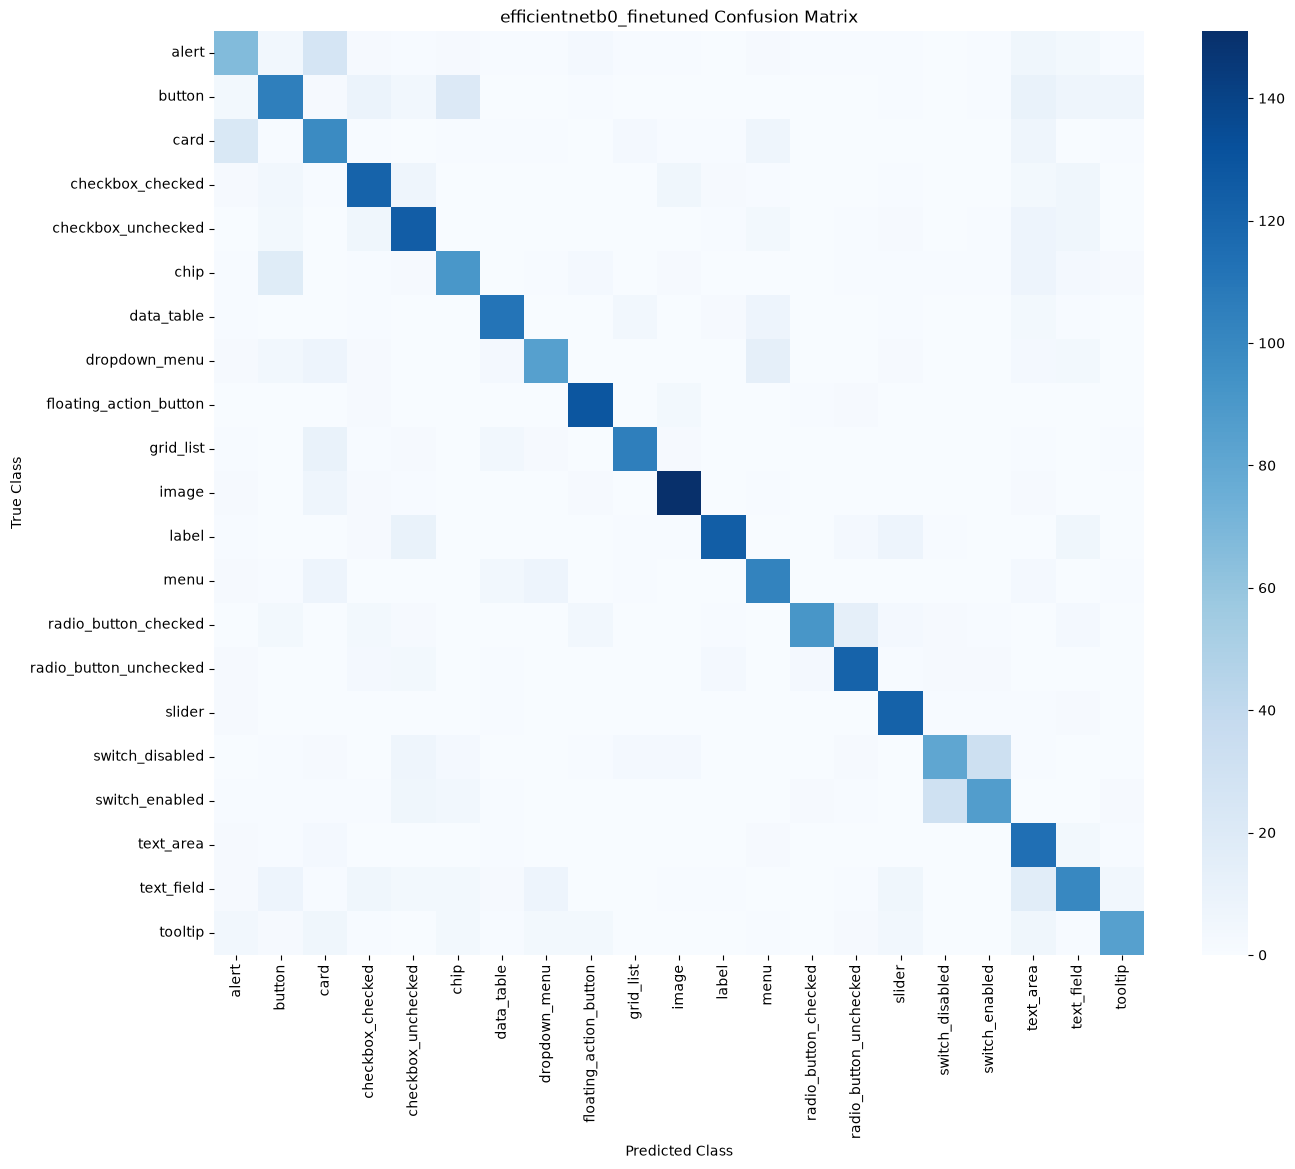

                        precision    recall  f1-score   support

                 alert       0.56      0.53      0.54       127
                button       0.65      0.60      0.63       174
                  card       0.56      0.67      0.61       146
      checkbox_checked       0.73      0.78      0.75       156
    checkbox_unchecked       0.71      0.79      0.75       158
                  chip       0.69      0.67      0.68       136
            data_table       0.83      0.83      0.83       134
         dropdown_menu       0.77      0.66      0.71       128
floating_action_button       0.87      0.93      0.90       138
             grid_list       0.88      0.80      0.84       131
                 image       0.88      0.90      0.89       168
                 label       0.92      0.78      0.85       158
                  menu       0.72      0.78      0.75       132
  radio_button_checked       0.93      0.70      0.80       131
radio_button_unchecked       0.81      

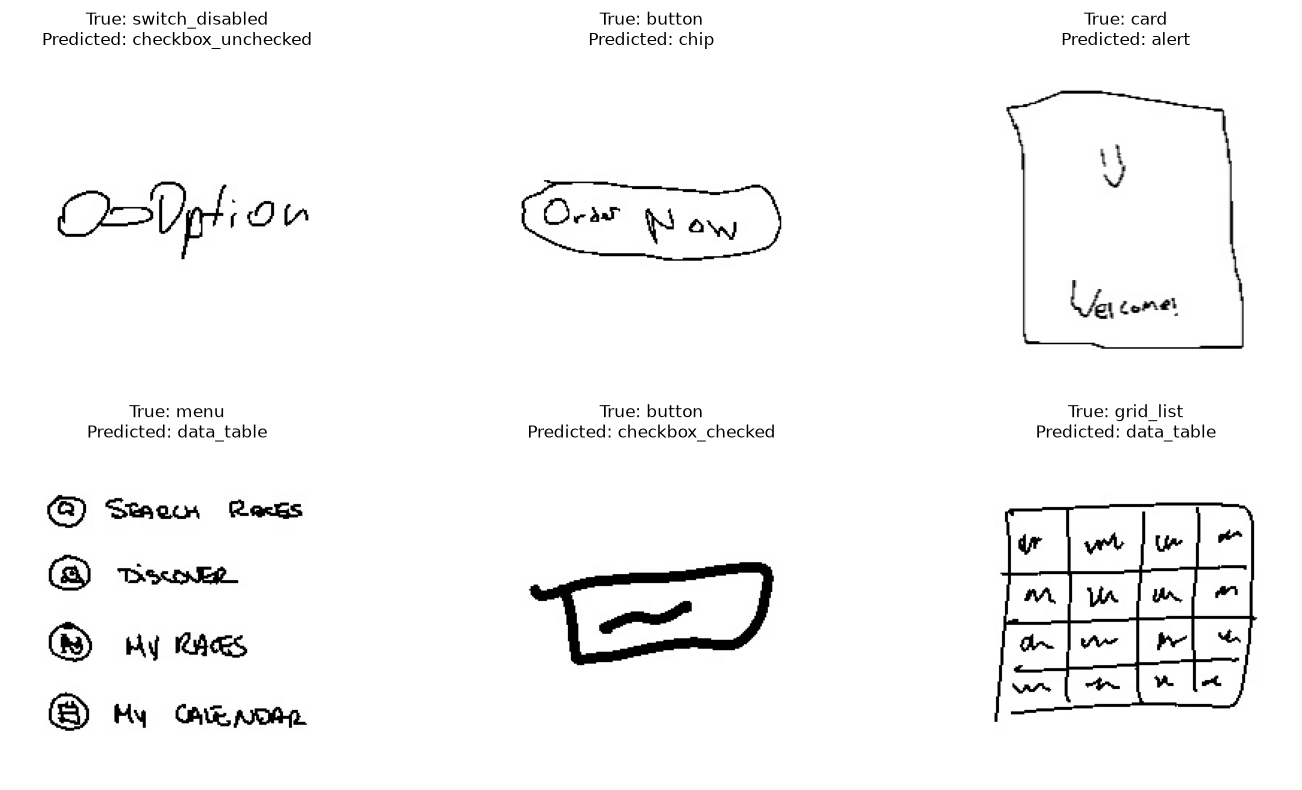

EfficientNetB0 fine-tuning time in minutes: 45.97


In [34]:


finetuned_metrics = None

if not RUN_EFFICIENTNET_FINE_TUNING:
    print("EfficientNetB0 fine-tuning is disabled in Phase 1 configuration.")

elif not efficientnet_head_trained_in_this_session:
    print("Fine-tuning skipped because EfficientNetB0 was not trained in this session.")
    print("Reason: trained model saving is disabled, so fine-tuning needs Phase 14 to run first in the same session.")

else:
    finetuned_metrics_file = REPORTS_FOLDER / "efficientnetb0_finetuned_metrics.csv"

    if SKIP_PHASE_IF_RESULT_EXISTS and finetuned_metrics_file.exists():
        print("Fine-tuned EfficientNetB0 metrics already exist. Skipping this phase.")
        finetuned_metrics = pd.read_csv(finetuned_metrics_file).iloc[0].to_dict()

    else:
        efficientnet_base_model.trainable = True

        for layer in efficientnet_base_model.layers[:-FINE_TUNE_LAST_LAYERS]:
            layer.trainable = False

        for layer in efficientnet_base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        efficientnet_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        fine_tuning_callbacks = [
            EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
            CSVLogger(filename=str(LOGS_FOLDER / "efficientnetb0_finetuned_training_log.csv"))
        ]

        start_time = time.time()
        fine_tuning_history = efficientnet_model.fit(
            train_data,
            validation_data=validation_data,
            epochs=EFFICIENTNET_FINE_TUNE_EPOCHS,
            callbacks=fine_tuning_callbacks,
            verbose=1
        )
        fine_tuning_time = round((time.time() - start_time) / 60, 2)

        fine_tuning_history_dataframe = save_training_history(
            fine_tuning_history,
            LOGS_FOLDER / "efficientnetb0_finetuned_training_history.csv"
        )
        plot_training_curves(fine_tuning_history_dataframe, "efficientnetb0_finetuned")

        finetuned_metrics, finetuned_true_labels, finetuned_predicted_labels, finetuned_probabilities = evaluate_model(
            efficientnet_model,
            test_data,
            class_names,
            "efficientnetb0_finetuned"
        )
        finetuned_metrics["training_time_minutes"] = fine_tuning_time

        save_dataframe(pd.DataFrame([finetuned_metrics]), finetuned_metrics_file)
        show_misclassified_examples(test_dataframe, finetuned_true_labels, finetuned_predicted_labels, class_names, "efficientnetb0_finetuned")

        print("EfficientNetB0 fine-tuning time in minutes:", fine_tuning_time)


## Phase 16: Optional Test-Time Augmentation

**Purpose:**  
This optional phase predicts each test image multiple times with light transformations and averages the predictions.  
It does not train or save a model.

In [37]:


tta_metrics = None


def predict_with_test_time_augmentation(model, test_dataset, number_of_passes=4):
    all_predictions = []

    for pass_number in range(number_of_passes):
        print(f"TTA pass {pass_number + 1}/{number_of_passes}")
        current_predictions = []

        for images, labels in test_dataset:
            if pass_number == 0:
                prediction_images = images
            else:
                prediction_images = data_augmentation(images, training=True)

            predictions = model.predict(prediction_images, verbose=0)
            current_predictions.append(predictions)

        all_predictions.append(np.concatenate(current_predictions, axis=0))

    return np.mean(all_predictions, axis=0)


if not RUN_TEST_TIME_AUGMENTATION:
    print("Test-Time Augmentation is disabled in Phase 1 configuration.")

elif not efficientnet_head_trained_in_this_session:
    print("TTA skipped because EfficientNetB0 was not trained in this session.")

else:
    tta_metrics_file = REPORTS_FOLDER / "efficientnetb0_tta_metrics.csv"

    tta_probabilities = predict_with_test_time_augmentation(
        efficientnet_model,
        test_data,
        number_of_passes=4
    )

    tta_predicted_labels = np.argmax(tta_probabilities, axis=1)
    tta_true_labels = np.concatenate([labels.numpy() for images, labels in test_data])

    tta_accuracy = accuracy_score(tta_true_labels, tta_predicted_labels)
    tta_precision, tta_recall, tta_macro_f1, _ = precision_recall_fscore_support(
        tta_true_labels,
        tta_predicted_labels,
        average="macro",
        zero_division=0
    )

    tta_metrics = {
        "model_name": "efficientnetb0_tta",
        "accuracy": float(tta_accuracy),
        "macro_precision": float(tta_precision),
        "macro_recall": float(tta_recall),
        "macro_f1_score": float(tta_macro_f1),
        "training_time_minutes": 0.0
    }

    save_dataframe(pd.DataFrame([tta_metrics]), tta_metrics_file)

    tta_report_text = classification_report(
        tta_true_labels,
        tta_predicted_labels,
        target_names=class_names,
        zero_division=0
    )
    save_text(tta_report_text, REPORTS_FOLDER / "efficientnetb0_tta_classification_report.txt")

    tta_matrix = confusion_matrix(tta_true_labels, tta_predicted_labels)
    tta_matrix_dataframe = pd.DataFrame(tta_matrix, index=class_names, columns=class_names)
    save_dataframe(tta_matrix_dataframe, REPORTS_FOLDER / "efficientnetb0_tta_confusion_matrix.csv", include_index=True)

    plt.figure(figsize=(15, 12))
    if sns is not None:
        sns.heatmap(tta_matrix_dataframe, cmap="Blues", annot=False, fmt="d")
    else:
        plt.imshow(tta_matrix, interpolation="nearest")
        plt.colorbar()
    plt.title("EfficientNetB0 Test-Time Augmentation Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    save_current_figure(FIGURES_FOLDER / "efficientnetb0_tta_confusion_matrix.png")
    plt.show()

    print(tta_report_text)

Test-Time Augmentation is disabled in Phase 1 configuration.


## Phase 17: Final Model Comparison Table

**Purpose:**  
This phase collects all available metric files and creates one model comparison table for the paper and presentation.

In [38]:


metric_files = [
    REPORTS_FOLDER / "custom_cnn_metrics.csv",
    REPORTS_FOLDER / "efficientnetb0_metrics.csv",
    REPORTS_FOLDER / "efficientnetb0_finetuned_metrics.csv",
    REPORTS_FOLDER / "efficientnetb0_tta_metrics.csv"
]

available_metric_tables = []

for metric_file in metric_files:
    if metric_file.exists():
        metric_table = pd.read_csv(metric_file)
        available_metric_tables.append(metric_table)
        print("Loaded:", metric_file.name)

if len(available_metric_tables) == 0:
    raise RuntimeError("No model metric files were found. Please run at least one training phase first.")

model_comparison_table = pd.concat(available_metric_tables, ignore_index=True)
model_comparison_table = model_comparison_table.sort_values(by="macro_f1_score", ascending=False)

save_dataframe(model_comparison_table, TABLES_FOLDER / "final_model_comparison_table.csv")
display(model_comparison_table)

Loaded: custom_cnn_metrics.csv
Loaded: efficientnetb0_metrics.csv
Loaded: efficientnetb0_finetuned_metrics.csv
Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/tables/final_model_comparison_table.csv


,model_name,accuracy,macro_precision,macro_recall,macro_f1_score,training_time_minutes
2,efficientnetb0_finetuned,0.742714,0.749953,0.743213,0.742275,45.97
1,efficientnetb0,0.701173,0.715934,0.701317,0.698139,70.12
0,custom_cnn,0.494137,0.507047,0.487541,0.482480,170.95


## Phase 18: Final Run Summary

**Purpose:**  
This phase saves a final JSON summary containing dataset size, split size, best model and saved outputs.

In [39]:


best_model_row = model_comparison_table.iloc[0]

final_run_summary = {
    "run_name": RUN_FOLDER.name,
    "run_folder": str(RUN_FOLDER),
    "total_images": int(len(dataset_dataframe)),
    "number_of_classes": int(number_of_classes),
    "train_images": int(len(train_dataframe)),
    "validation_images": int(len(validation_dataframe)),
    "test_images": int(len(test_dataframe)),
    "image_size": int(IMAGE_SIZE),
    "batch_size": int(BATCH_SIZE),
    "custom_cnn_epochs": int(CUSTOM_CNN_EPOCHS),
    "efficientnet_head_epochs": int(EFFICIENTNET_HEAD_EPOCHS),
    "efficientnet_fine_tune_epochs": int(EFFICIENTNET_FINE_TUNE_EPOCHS),
    "fine_tune_last_layers": int(FINE_TUNE_LAST_LAYERS),
    "model_saving": "Disabled by design",
    "best_model_by_macro_f1": str(best_model_row["model_name"]),
    "best_accuracy": float(best_model_row["accuracy"]),
    "best_macro_f1_score": float(best_model_row["macro_f1_score"]),
    "saved_outputs": [
        "dataset summary",
        "class distribution",
        "dataset samples",
        "train/validation/test split",
        "training logs",
        "training curves",
        "classification reports",
        "confusion matrices",
        "misclassified examples",
        "model comparison table"
    ]
}

save_json(final_run_summary, LOGS_FOLDER / "final_run_summary.json")
print(json.dumps(final_run_summary, indent=4))

Saved: /Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12/logs/final_run_summary.json
{
    "run_name": "run_2026-06-30_14-57-12",
    "run_folder": "/Users/anjali/Desktop/Anjali_CV_Project_WS/outputs/run_2026-06-30_14-57-12",
    "total_images": 19898,
    "number_of_classes": 21,
    "train_images": 13928,
    "validation_images": 2985,
    "test_images": 2985,
    "image_size": 224,
    "batch_size": 32,
    "custom_cnn_epochs": 25,
    "efficientnet_head_epochs": 12,
    "efficientnet_fine_tune_epochs": 8,
    "fine_tune_last_layers": 30,
    "model_saving": "Disabled by design",
    "best_model_by_macro_f1": "efficientnetb0_finetuned",
    "best_accuracy": 0.742713567839196,
    "best_macro_f1_score": 0.742274663148898,
    "saved_outputs": [
        "dataset summary",
        "class distribution",
        "dataset samples",
        "train/validation/test split",
        "training logs",
        "training curves",
        "classification reports",
        "

## Phase 19: Possible Next Steps

